# 10 · Yan etki: çözüm yeni bir sorun yarattı mı?

09'da kestirme öğrenmeyi kırdık: v3 artık İHA'yı asfaltta, sokakta, toprakta buluyor (100/100 kare, görülmemiş İHA'larda 23/24).

Ama her müdahalenin bir bedeli olabilir. Bu sayfada **tersini** soruyoruz: model artık gökyüzündeki *başka* nesneleri de doğru tanıyor mu, yoksa hepsine "İHA" mı diyor?

**Neden şüphelendik?** Ürettiğimiz 1.500 yapay fotoğrafın **hepsinde** yapıştırılan nesne İHA'ydı. Modele "farklı arka planlarda İHA olabilir" dedik; ama "gökyüzünde İHA olmayan şeyler de olabilir" demedik. Eğitim verisinde gökyüzü fotoğraflarında hâlâ **yalnızca** İHA var.

v3'ün karışıklık matrisi de ipucu veriyordu: `drone` için yanlış alarm **8'den 28'e** çıkmıştı.

## 1. Hazırlık

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, random
from ultralytics import YOLO

klasor = "../data/kucuk_paket"
SINIF = {0:"person", 1:"car", 2:"bicycle", 3:"other_vehicle", 4:"drone", 5:"mine", 6:"gun"}

def oku(ad, bolum="train"):
    foto = cv2.imread(f"{klasor}/images/{bolum}/{ad}.png")
    yukseklik, genislik = foto.shape[0], foto.shape[1]
    kutular = []
    with open(f"{klasor}/labels/{bolum}/{ad}.txt") as dosya:
        for satir in dosya.read().splitlines():
            p = satir.split()
            n = int(p[0])
            mx, my = float(p[1])*genislik, float(p[2])*yukseklik
            g, y = float(p[3])*genislik, float(p[4])*yukseklik
            kutular.append((n, round(mx-g/2), round(my-y/2), round(mx+g/2), round(my+y/2)))
    return foto, kutular

v1 = YOLO("../models/iha_yolo11n.pt")          # yapay verisiz
v3 = YOLO("../models/iha_yolo11n_v3.pt")       # 1.500 yapay fotoğrafla eğitilmiş
print("hazır")

hazır


## 2. Test: araba ve insanı gökyüzüne yapıştır

09'daki deneyin **tersi**: bu sefer İHA değil, `car` ve `person` kesitlerini alıp **gökyüzü** fotoğraflarına yapıştırıyoruz. Doğru cevap belli: model onlara `car` / `person` demeli.

In [2]:
# --- araba ve insan kesitleri (val/test bölümünden) ---
kesitler = {"car": [], "person": []}
for bolum in ["val", "test"]:
    for d in sorted(os.listdir(f"{klasor}/labels/{bolum}")):
        ad = d[:-4]
        foto, kutular = oku(ad, bolum)
        for (n, a, b, c, e) in kutular:
            if (e-b) >= 28 and (c-a) >= 28:                  # yeterince büyük kesitler
                if n == 1 and len(kesitler["car"]) < 40:
                    kesitler["car"].append(foto[b:e, a:c].copy())
                elif n == 0 and len(kesitler["person"]) < 40:
                    kesitler["person"].append(foto[b:e, a:c].copy())

gokyuzu = [d.rsplit(".", 1)[0] for d in sorted(os.listdir(f"{klasor}/images/train"))
           if d.startswith("01_uav2uav")]                    # gökyüzü arka planları

print("araba kesiti:", len(kesitler["car"]), "| insan kesiti:", len(kesitler["person"]),
      "| gökyüzü arka planı:", len(gokyuzu))


def ters_test(model, sinif_adi):
    """Verilen sınıfın kesitlerini gökyüzüne yapıştırır, modelin ne dediğini sayar"""
    dogru = toplam = 0
    digerleri = {}
    for i, kesit in enumerate(kesitler[sinif_adi][:8]):       # 8 kesit
        for j, arka_ad in enumerate(gokyuzu[:3]):             # 3 arka plan
            arka, _ = oku(arka_ad)
            h, w = arka.shape[0], arka.shape[1]
            kh, kw = kesit.shape[0], kesit.shape[1]
            if kh >= h-30 or kw >= w-30:
                continue
            random.seed(700 + i*10 + j)
            x = random.randint(15, w-kw-15)
            y = random.randint(15, h-kh-15)
            im = arka.copy(); im[y:y+kh, x:x+kw] = kesit      # gökyüzüne yapıştır

            sonuc = model(im, verbose=False)[0]
            toplam += 1
            yakin = [model.names[int(k.cls)] for k in sonuc.boxes
                     if k.xyxy[0][0] < x+kw+20 and k.xyxy[0][2] > x-20
                     and k.xyxy[0][1] < y+kh+20 and k.xyxy[0][3] > y-20]
            if sinif_adi in yakin:
                dogru += 1
            else:
                anahtar = yakin[0] if yakin else "—"
                digerleri[anahtar] = digerleri.get(anahtar, 0) + 1
    return dogru, toplam, digerleri


for sinif_adi in ["car", "person"]:
    print(f"\n=== {sinif_adi.upper()} → GÖKYÜZÜ ===")
    for isim, model in [("v1", v1), ("v3", v3)]:
        d, t, dg = ters_test(model, sinif_adi)
        print(f"  {isim}: {t} denemenin {d} tanesinde '{sinif_adi}' | diğer tahminler: {dg}")

araba kesiti: 40 | insan kesiti: 40 | gökyüzü arka planı: 43

=== CAR → GÖKYÜZÜ ===


  v1: 24 denemenin 11 tanesinde 'car' | diğer tahminler: {'drone': 4, '—': 9}


  v3: 24 denemenin 2 tanesinde 'car' | diğer tahminler: {'drone': 17, '—': 5}

=== PERSON → GÖKYÜZÜ ===


  v1: 24 denemenin 14 tanesinde 'person' | diğer tahminler: {'—': 6, 'drone': 4}


  v3: 24 denemenin 12 tanesinde 'person' | diğer tahminler: {'drone': 11, '—': 1}


**Sonuç:** v3, gökyüzüne konan arabaların büyük kısmına **`drone`** diyor. v1 ise daha isabetli.

İki ayrı kestirme olduğu ortaya çıkıyor:

| Kestirme | v1 | v3 |
|---|---|---|
| A: "İHA sadece gökyüzünde bulunur" | var ❌ | **kırıldı** ✅ |
| B: "Gökyüzünde bir şey varsa o İHA'dır" | var ❌ | **hâlâ var**, güçlendi ❌ |

Biz yalnızca A'yı hedefledik, B'ye dokunmadık.

## 3. Görsel: model gökyüzündeki arabaya ne diyor?

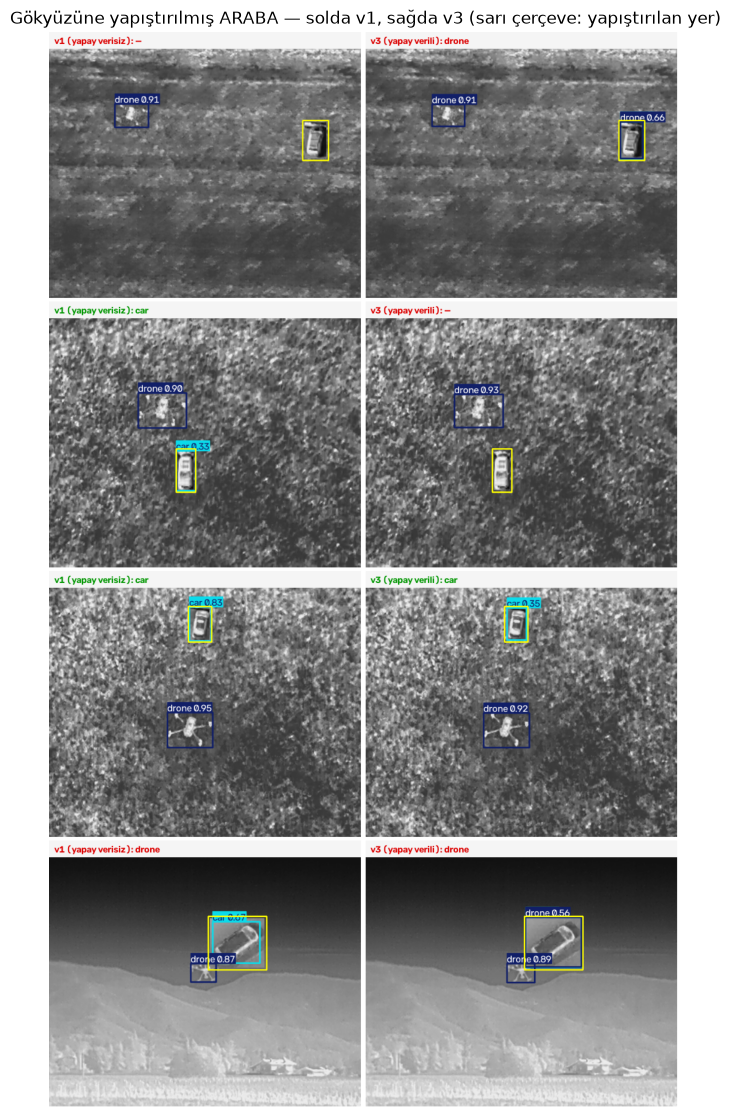

In [3]:
def panel(sinif_adi, kac=4):
    satirlar = []
    for i in range(kac):
        kesit = kesitler[sinif_adi][i]
        arka, _ = oku(gokyuzu[i % len(gokyuzu)])
        h, w = arka.shape[0], arka.shape[1]
        kh, kw = kesit.shape[0], kesit.shape[1]
        random.seed(50 + i)
        x = random.randint(15, w-kw-15); y = random.randint(15, h-kh-15)
        im = arka.copy(); im[y:y+kh, x:x+kw] = kesit

        goruntuler = []
        for model, isim in [(v1, "v1 (yapay verisiz)"), (v3, "v3 (yapay verili)")]:
            sonuc = model(im, verbose=False)[0]
            ciz = sonuc.plot()
            cv2.rectangle(ciz, (x-4, y-4), (x+kw+4, y+kh+4), (0, 255, 255), 2)   # sarı: yapıştırılan yer
            yakin = [model.names[int(k.cls)] for k in sonuc.boxes
                     if k.xyxy[0][0] < x+kw+20 and k.xyxy[0][2] > x-20
                     and k.xyxy[0][1] < y+kh+20 and k.xyxy[0][3] > y-20]
            tahmin = yakin[0] if yakin else "—"
            dogru = (tahmin == sinif_adi)
            ciz = cv2.resize(ciz, (520, int(520*h/w)))
            ust = np.full((28, 520, 3), 245, np.uint8)
            cv2.putText(ust, f"{isim}: {tahmin}", (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (0, 150, 0) if dogru else (0, 0, 220), 2)
            goruntuler.append(np.vstack([ust, ciz]))

        yuk = max(g.shape[0] for g in goruntuler)
        goruntuler = [cv2.copyMakeBorder(g, 0, yuk-g.shape[0], 0, 8,
                                         cv2.BORDER_CONSTANT, value=(255,255,255)) for g in goruntuler]
        satirlar.append(np.hstack(goruntuler))

    W = max(s.shape[1] for s in satirlar)
    satirlar = [cv2.copyMakeBorder(s, 0, 6, 0, W-s.shape[1], cv2.BORDER_CONSTANT, value=(255,255,255))
                for s in satirlar]
    return np.vstack(satirlar)


gorsel = panel("car", 4)
cv2.imwrite("../egitim_sonuclari/deneyler/yan_etki_araba.jpg", gorsel)

plt.figure(figsize=(16, 14))
plt.imshow(cv2.cvtColor(gorsel, cv2.COLOR_BGR2RGB))
plt.title("Gökyüzüne yapıştırılmış ARABA — solda v1, sağda v3 (sarı çerçeve: yapıştırılan yer)")
plt.axis("off")
plt.show()

Sarı çerçevenin içinde net bir araba var: tekerlekler, cam, gövde. v3 buna `drone` diyor.

Sebep, modelin öğrendiği kuralın hâlâ bağlam içermesi: **"gökyüzü sahnesinde bir nesne varsa drone'dur."** Yapay veri bu tarafı hiç zorlamadı.

## 4. Çözüm: karşı örnekler

Bir kestirmeyi tam kırmak için **iki yönlü** örnek gerekiyor:

| Ürettiğimiz (v3) | Eksik olan (v4) |
|---|---|
| İHA → otopark, sokak, toprak | **Araba, insan, bisiklet → gökyüzü** |

Yani gökyüzüne araba yapıştırıp etiketine `1` (car) yazmak. Böylece "gökyüzü = drone" denklemi de kırılır. Buna **karşı örnek** (counter-example) denir.

Aşağıdaki kod bu örnekleri üretiyor: nesne gökyüzüne konuyor ama **kendi sınıfıyla** etiketleniyor. Gökyüzündeki gerçek İHA'ların etiketleri de korunuyor.

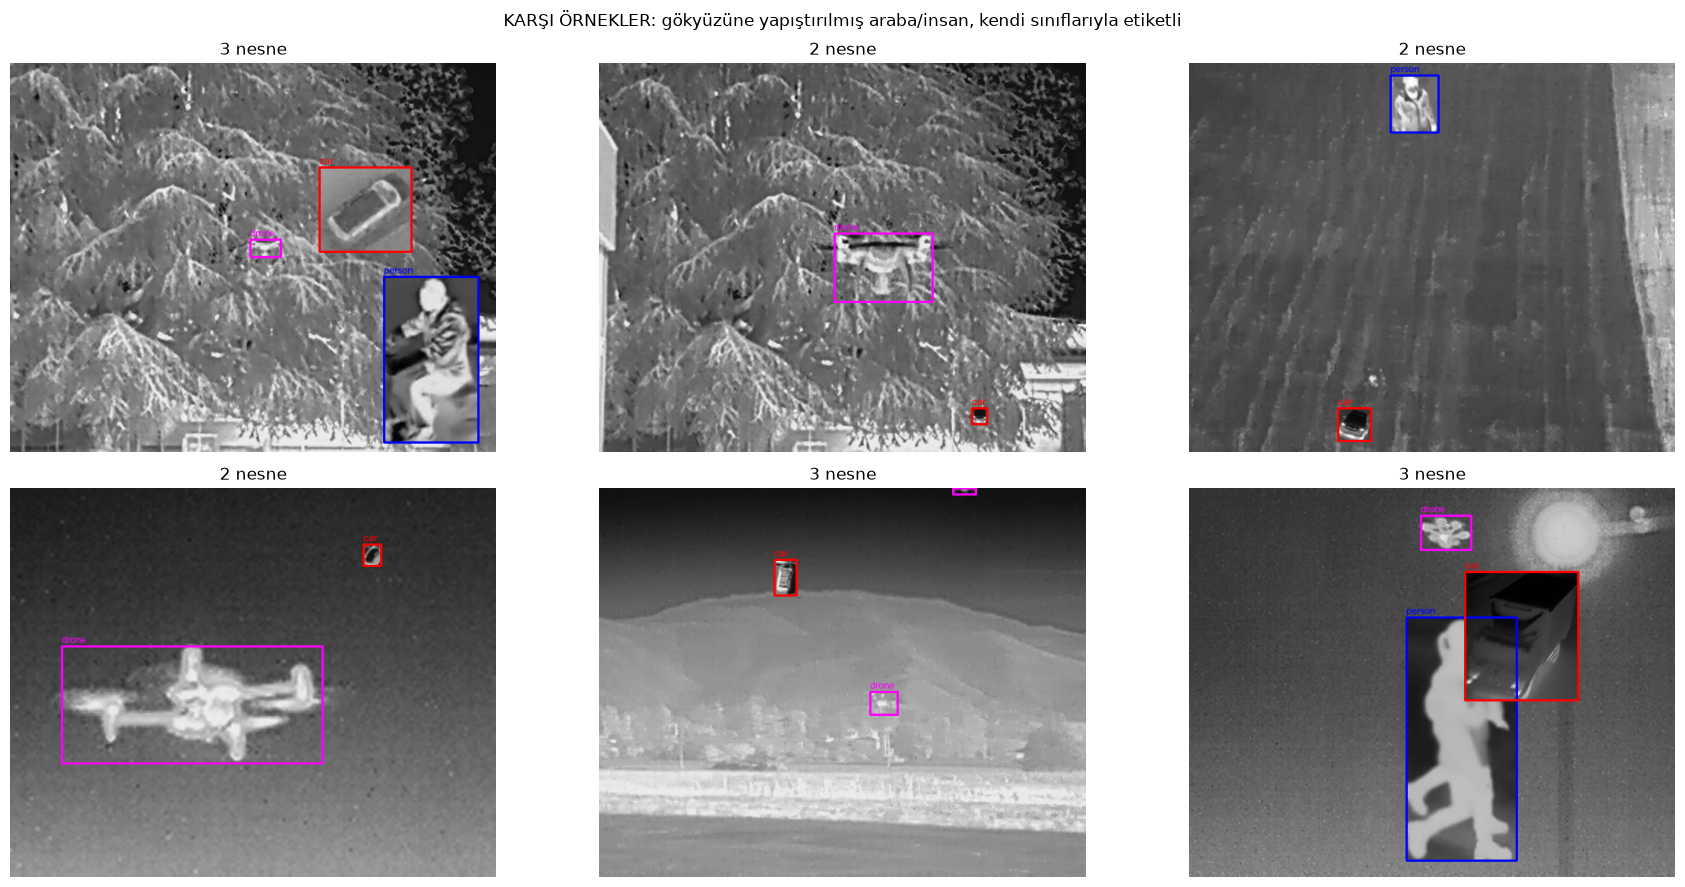

In [4]:
def karsi_ornek_uret(arka_ad, adet=2):
    """Gökyüzü fotoğrafına drone OLMAYAN nesneler yapıştırır, kendi sınıflarıyla etiketler"""
    arka, mevcut = oku(arka_ad)
    h, w = arka.shape[0], arka.shape[1]
    im = arka.copy()

    etiketler = []
    for (n, x1, y1, x2, y2) in mevcut:                       # gökyüzündeki GERÇEK İHA'lar korunur
        etiketler.append((n, x1, y1, x2, y2))

    havuz = [(1, k) for k in kesitler["car"]] + [(0, k) for k in kesitler["person"]]
    for _ in range(adet):
        sinif, kesit = random.choice(havuz)
        olcek = random.uniform(0.5, 1.2)
        kesit = cv2.resize(kesit, (max(16, int(kesit.shape[1]*olcek)),
                                   max(16, int(kesit.shape[0]*olcek))))
        kh, kw = kesit.shape[0], kesit.shape[1]
        if kh >= h-20 or kw >= w-20:
            continue
        x = random.randint(10, w-kw-10); y = random.randint(10, h-kh-10)
        im[y:y+kh, x:x+kw] = kesit
        etiketler.append((sinif, x, y, x+kw, y+kh))          # KENDİ sınıfıyla etiketlenir

    return im, etiketler


random.seed(5)
fig, eksenler = plt.subplots(2, 3, figsize=(18, 9))
for eksen in eksenler.flat:
    ad = random.choice(gokyuzu)
    im, etiketler = karsi_ornek_uret(ad, random.randint(1, 2))
    ciz = im.copy()
    for (n, x1, y1, x2, y2) in etiketler:
        renk = (255, 0, 255) if n == 4 else (0, 0, 255) if n == 1 else (255, 0, 0)
        cv2.rectangle(ciz, (x1, y1), (x2, y2), renk, 2)
        cv2.putText(ciz, SINIF[n], (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, renk, 1)
    eksen.imshow(cv2.cvtColor(ciz, cv2.COLOR_BGR2RGB))
    eksen.set_title(f"{len(etiketler)} nesne")
    eksen.axis("off")
plt.suptitle("KARŞI ÖRNEKLER: gökyüzüne yapıştırılmış araba/insan, kendi sınıflarıyla etiketli")
plt.tight_layout()
plt.show()

## 5. Çözüm: v4 — karşı örneklerle eğitim

Teşhis nettir: modelin gördüğü gökyüzü fotoğraflarında **yalnızca** İHA var. O halde gökyüzüne başka nesneler de koymalıyız.

**Üretim (Kaggle'da):** 750 karşı örnek — gökyüzü fotoğraflarına araba, insan ve bisiklet kesitleri yapıştırıldı, her biri **kendi sınıfıyla** etiketlendi. Gökyüzündeki gerçek İHA'ların etiketleri korundu.

**Deney zinciri — her adımda tek değişken:**

| | v1 | v3 | **v4** |
|---|---|---|---|
| Gerçek fotoğraf | 3.000 | 3.000 | 3.000 |
| İHA → farklı arka planlar | 0 | 1.500 | 1.500 |
| **Karşı örnek (nesne → gökyüzü)** | 0 | 0 | **750** |
| Model / epoch / batch / imgsz | yolo11n · 20 · 32 · 640 | aynı | aynı |

**Doğrulama setindeki sonuçlar:**

| | v1 | v3 | **v4** |
|---|---|---|---|
| mAP50 (genel) | 0.789 | 0.797 | 0.790 |
| **drone** | 0.938 | 0.919 | **0.954** |
| car | 0.918 | 0.918 | 0.918 |
| person | 0.935 | 0.934 | 0.934 |

`drone` sınıfı hem v1'i hem v3'ü geçti. Genel mAP50 aynı seviyede: bir yeri düzeltirken başka yer bozulmadı.

### 5.1 İki yönlü test: v1 · v3 · v4

In [5]:
v4 = YOLO("../models/iha_yolo11n_v4.pt")       # 3.000 gerçek + 1.500 İHA + 750 karşı örnek

print("=== TERS TEST: nesne → GÖKYÜZÜ (yan etkinin ölçümü) ===")
for sinif_adi in ["car", "person"]:
    print(f"\n  {sinif_adi}:")
    for isim, model in [("v1", v1), ("v3", v3), ("v4", v4)]:
        d, t, dg = ters_test(model, sinif_adi)
        print(f"     {isim}: {d}/{t} doğru | diğer tahminler: {dg}")

=== TERS TEST: nesne → GÖKYÜZÜ (yan etkinin ölçümü) ===

  car:


     v1: 11/24 doğru | diğer tahminler: {'drone': 4, '—': 9}


     v3: 2/24 doğru | diğer tahminler: {'drone': 17, '—': 5}


     v4: 22/24 doğru | diğer tahminler: {'drone': 1, 'person': 1}

  person:


     v1: 14/24 doğru | diğer tahminler: {'—': 6, 'drone': 4}


     v3: 12/24 doğru | diğer tahminler: {'drone': 11, '—': 1}


     v4: 24/24 doğru | diğer tahminler: {}


**Sonuç:**

| Gökyüzüne yapıştırılan | v1 | v3 | **v4** |
|---|---|---|---|
| **car** doğru bilinen | 11/24 | 2/24 | **22/24** |
| **person** doğru bilinen | 14/24 | 12/24 | **24/24** |

v3'te gökyüzündeki arabaların 17'sine `drone` deniyordu; v4'te bu sayı **1**'e düştü. İnsanlarda sonuç kusursuz: 24/24.

Dikkat çeken nokta: v4 yalnızca v3'ün hatasını düzeltmedi, **v1'i de geçti**. Karşı örnekler modele başlangıçta hiç sahip olmadığı bir ayırt etme yeteneği kazandırdı.

### 5.2 v3'ün kazanımı korundu mu?
Yan etkiyi düzeltirken asıl kazanımı kaybetmiş olabiliriz. Kontrol edelim.

In [6]:
# İHA'yı gökyüzü OLMAYAN sahnelere yapıştır — v3'teki testin aynısı
iha, ks = oku("01_uav2uav__430__864a7aebf1")
parca = iha[ks[0][2]:ks[0][4], ks[0][1]:ks[0][3]].copy()
ph, pw = parca.shape[0], parca.shape[1]
otopark, _ = oku("02_hituav__0_100_50_0_08164__c5427da128")

print("=== VİDEO: İHA otopark arka planında, 100 kare ===")
for isim, model in [("v1", v1), ("v3", v3), ("v4", v4)]:
    bulunan = 0
    for i in range(100):
        kare = otopark.copy()
        x = 20 + int(i * (640 - pw - 40) / 100)
        y = 60 + int(i * 320 / 100)
        kare[y:y+ph, x:x+pw] = parca
        sonuc = model(kare, verbose=False)[0]
        if any(model.names[int(k.cls)] == "drone" for k in sonuc.boxes):
            bulunan += 1
    print(f"   {isim}: {bulunan}/100 karede drone bulundu")

=== VİDEO: İHA otopark arka planında, 100 kare ===


   v1: 1/100 karede drone bulundu


   v3: 100/100 karede drone bulundu


   v4: 100/100 karede drone bulundu


**Sonuç: v1 → 1/100, v3 → 100/100, v4 → 100/100.**

Kazanım korundu. Görülmemiş İHA kesitleriyle yapılan genelleme testinde de v4 aynı skoru veriyor: **23/24, ortalama güven 0.95**.

### 5.3 Görseller

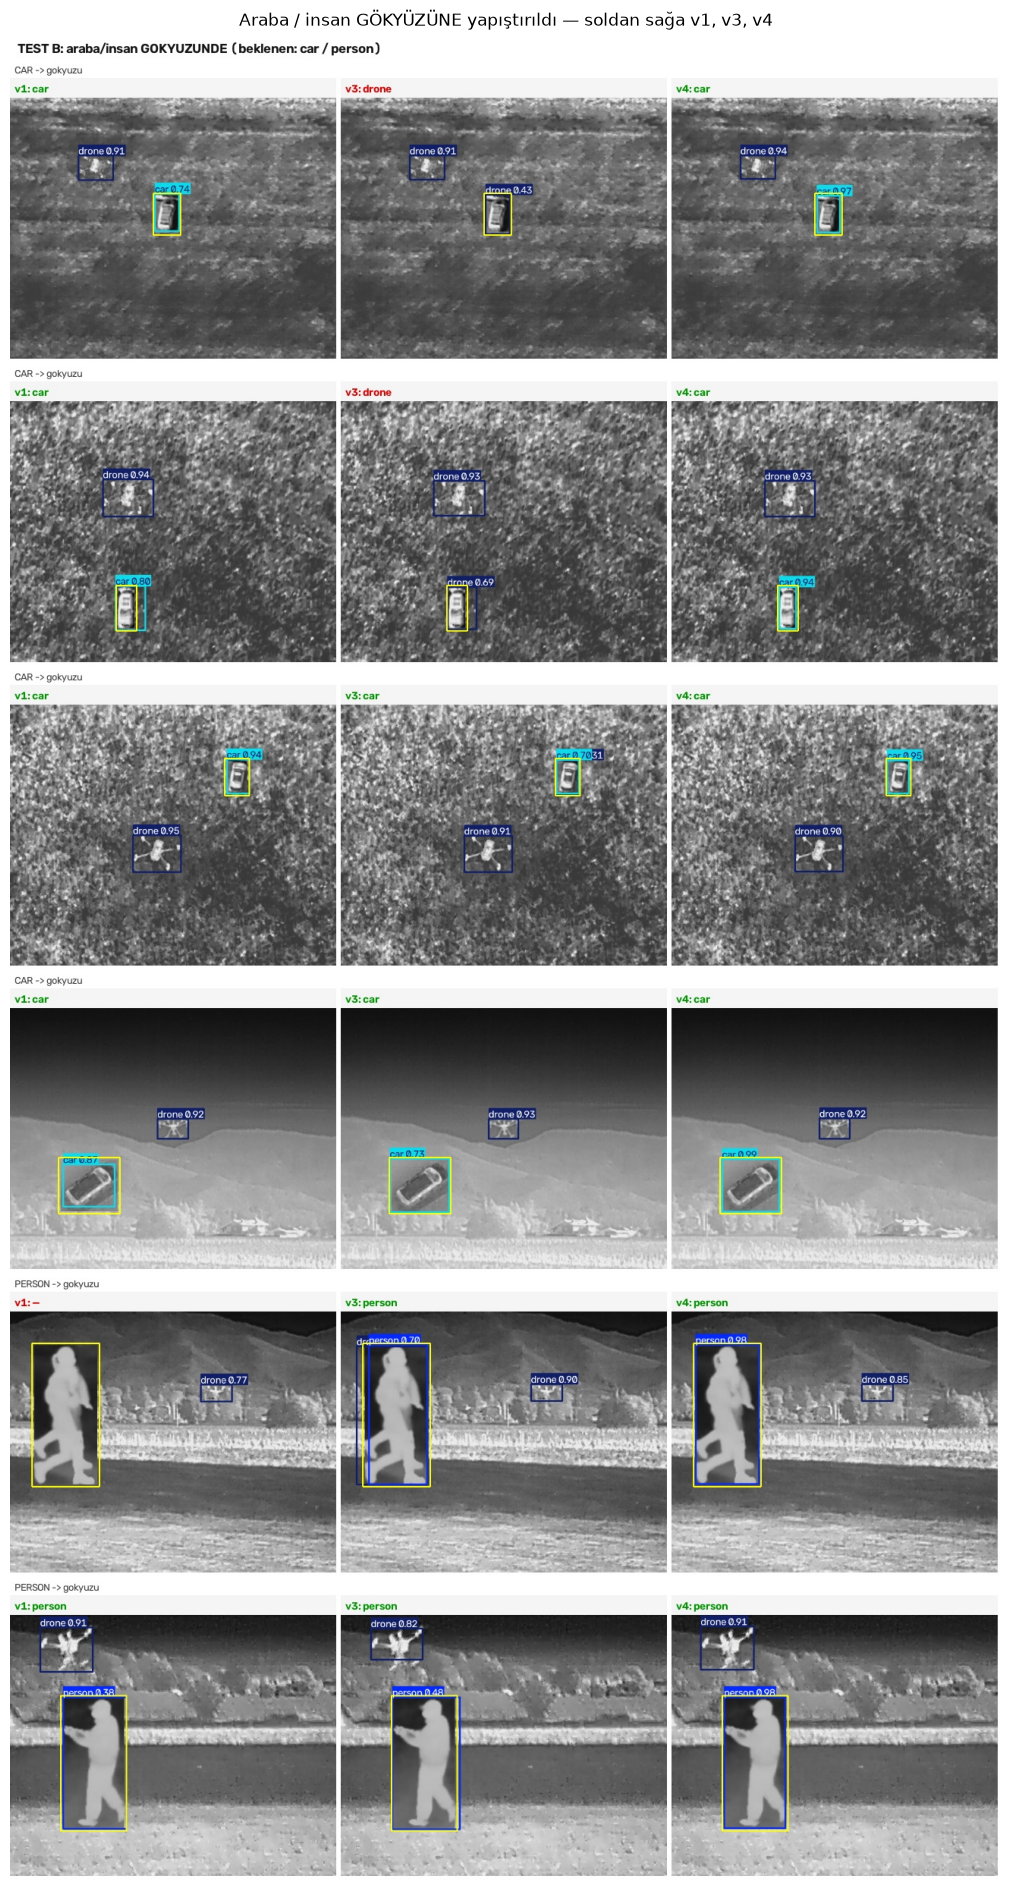

In [7]:
def gorsel(dosya, baslik, boyut=(17, 24)):
    resim = plt.imread("../egitim_sonuclari/deneyler/" + dosya)
    plt.figure(figsize=boyut)
    plt.imshow(resim)
    plt.title(baslik)
    plt.axis("off")
    plt.show()

gorsel("v4_test_gokyuzu.jpg", "Araba / insan GÖKYÜZÜNE yapıştırıldı — soldan sağa v1, v3, v4")

**Satır satır okunuşu:**

| Satır | v1 | v3 | v4 |
|---|---|---|---|
| 1 — araba, gökyüzü | `car 0.74` | **`drone 0.43`** ❌ | `car 0.97` ✅ |
| 2 — araba, benekli zemin | `car 0.80` | **`drone 0.69`** ❌ | `car 0.94` ✅ |
| 5 — insan, gökyüzü | **bulamadı** ❌ | `person 0.70` | `person 0.98` ✅ |
| 6 — insan | `person 0.38` | `person 0.48` | `person 0.98` ✅ |

Her karede sahnenin **kendi gerçek İHA'sı** da doğru kutulanmaya devam ediyor (mavi `drone` kutuları). v4 gökyüzündeki arabayı ayırt ederken İHA'yı kaybetmiyor — asıl zor olan buydu.

Güven skorlarına da dikkat: v4 hem doğru sınıfı buluyor hem daha emin (0.74 → 0.97, 0.38 → 0.98).

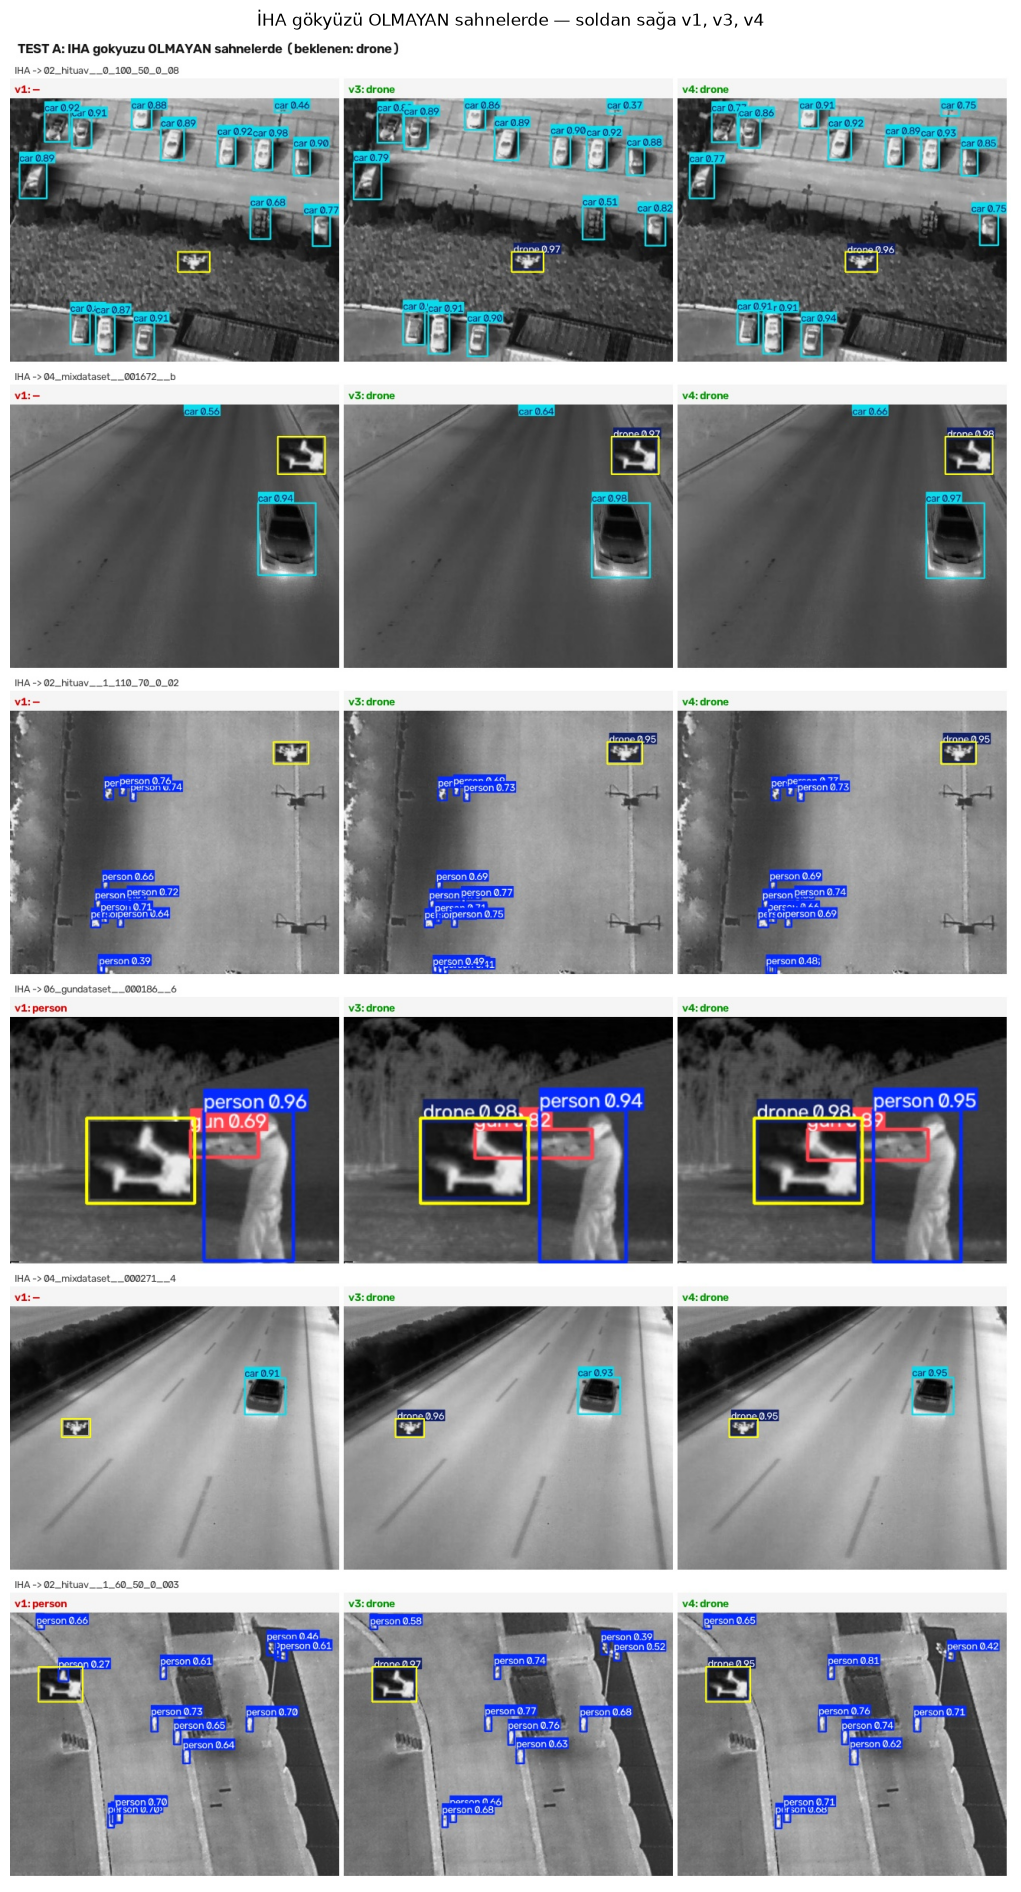

In [8]:
gorsel("v4_test_iha.jpg", "İHA gökyüzü OLMAYAN sahnelerde — soldan sağa v1, v3, v4")

v4, v3'ün bütün kazanımlarını koruyor: İHA otoparkta, sokakta, toprakta tanınmaya devam ediyor.

### 5.4 v4 eğitim grafikleri

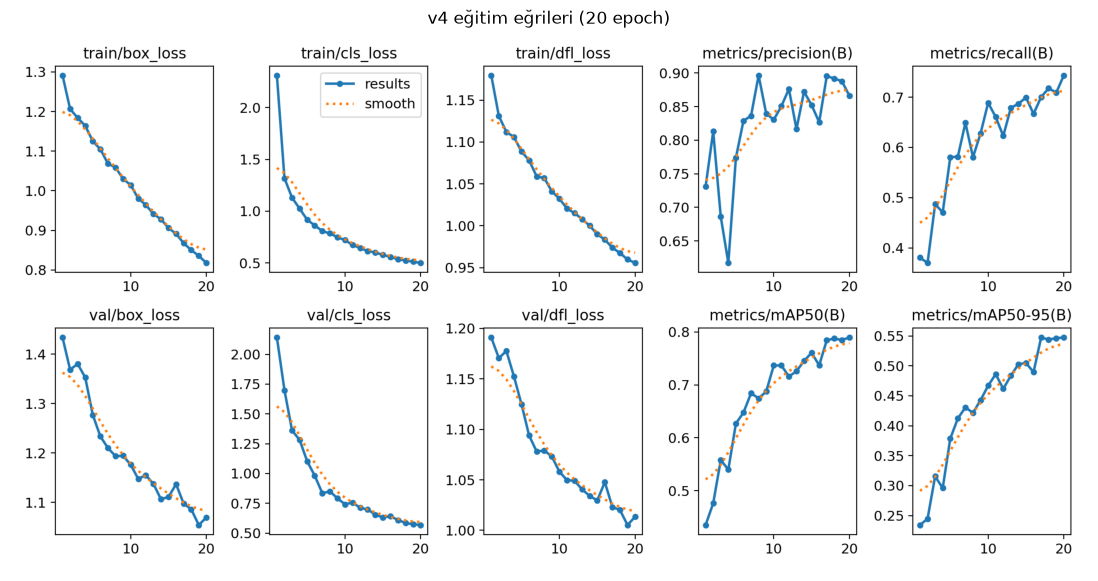

In [9]:
def v4_grafik(dosya, baslik, boyut=(15, 7)):
    plt.figure(figsize=boyut)
    plt.imshow(plt.imread("../egitim_sonuclari/v4/" + dosya))
    plt.title(baslik)
    plt.axis("off")
    plt.show()

v4_grafik("results.png", "v4 eğitim eğrileri (20 epoch)")

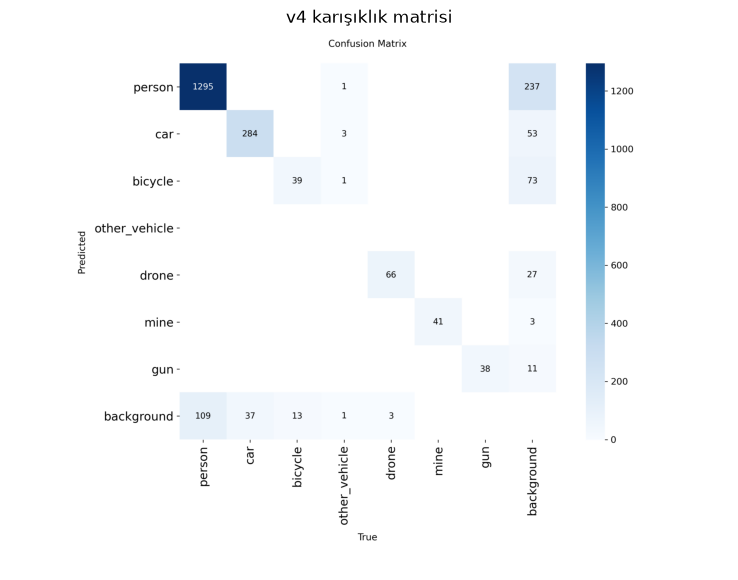

In [10]:
v4_grafik("confusion_matrix.png", "v4 karışıklık matrisi")

**Karışıklık matrisinde v3 → v4 değişimi:**

| | v3 | v4 |
|---|---|---|
| drone doğru | 62 | **66** |
| drone yanlış alarm | 28 | **27** |
| car yanlış alarm | 78 | **53** |
| person yanlış alarm | 259 | **237** |

Yanlış alarmlar üç sınıfta birden azaldı. Model daha seçici hale geldi: artık her parlak lekeye bir isim yapıştırmıyor.

## Sonuç

### Hikâyenin tamamı

| # | Adım | Sonuç |
|---|---|---|
| 1 | Model eğitildi (v1) | drone mAP50 **0.94** — görünüşte başarılı |
| 2 | Kestirme şüphesi, kopyala-yapıştır testi | İHA asfaltta **tanınmıyor** |
| 3 | Teşhis | "gökyüzü = İHA" kısayolu |
| 4 | Daha çok veri (v2: 10.000 foto, 40 epoch) | Kestirme **düzelmedi** → sorun miktar değil, çeşitlilik |
| 5 | Yapay veri: İHA → farklı arka planlar (v3) | 0/100 → **100/100** ✅ |
| 6 | Yan etki ölçümü | Gökyüzündeki arabaya `drone` diyor ❌ |
| 7 | Karşı örnek: nesne → gökyüzü (v4) | **İkisi de düzeldi** ✅✅ |

### Son durum

| Test | v1 | v3 | **v4** |
|---|---|---|---|
| İHA gökyüzü olmayan sahnelerde (5 sahne) | 2/5 | 5/5 | **5/5** |
| İHA video, otopark arka planı (100 kare) | 1/100 | 100/100 | **100/100** |
| Görülmemiş İHA kesitleri (24 deneme) | 5/24 | 23/24 | **23/24** |
| Gökyüzünde araba doğru bilinen (24) | 11/24 | 2/24 | **22/24** |
| Gökyüzünde insan doğru bilinen (24) | 14/24 | 12/24 | **24/24** |
| Doğrulama mAP50 | 0.789 | 0.797 | 0.790 |
| Doğrulama drone mAP50 | 0.938 | 0.919 | **0.954** |

### Çıkarımlar

1. **Yüksek mAP, sağlam model demek değil.** v1 drone sınıfında 0.94 alıyordu ama bağlam değişince çuvallıyordu. Standart ölçümler bunu göstermez; bağlam dışı test tasarlamak gerekir.
2. **Veri miktarı her sorunu çözmez.** Üç kat veri kestirmeyi kırmadı; çeşitlilik gerekti.
3. **Bir kestirmeyi kırmak için iki yönlü örnek gerekir.** "Nesne başka bağlamlarda da olur" yetmedi; "bu bağlamda başka nesneler de olur" da gerekti.
4. **Her müdahalenin yan etkisi ölçülmeli.** v3'ü "sorun çözüldü" diye bırakmak, yeni bir hatayı fark etmemek olurdu.

### Yöntemin sınırları

- Yapıştırma kenarları keskin; model "yama" artefaktını öğrenmiş olabilir
- Işık, gölge ve perspektif tutarsız
- Bütün kesitler aynı veri setinden, yani aynı kamera ve çekim koşullarından geliyor
- Karşı örnekler yalnızca 3 sınıftan üretildi (car, person, bicycle); mine ve gun için benzer bir test yapılmadı